# Task 5: Exploratory Data Analysis (EDA) — Titanic Dataset

**Internship:** Elevate Labs — Data Analyst Internship
**Objective:** Extract insights using visual and statistical exploration.
**Tools:** Python (Pandas, Matplotlib, Seaborn)
**Dataset:** Titanic Dataset


## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('titanic.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Basic Structure — `.info()`, `.describe()`, `.value_counts()`

We start by understanding the shape, data types, missing values, and basic statistics of the dataset.


In [2]:
print("Shape of dataset:", df.shape)
df.info()


Shape of dataset: (891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [3]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [4]:
# Missing values check
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})


,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


**Observation:** `Cabin` has a very high percentage of missing values (~77%), `Age` has moderate missing values (~20%), and `Embarked` has only 2 missing values. Cabin will likely be dropped or heavily engineered, Age will need imputation, and Embarked can be filled with the mode.


In [5]:
df['Survived'].value_counts()


Survived
0    549
1    342
Name: count, dtype: int64

In [6]:
df['Pclass'].value_counts()


Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [7]:
df['Sex'].value_counts()


Sex
male      577
female    314
Name: count, dtype: int64

**Observation:** More passengers did not survive (549) than survived (342) — roughly a 62%/38% split. Class 3 (lowest class) has the most passengers, and there are more male passengers than female passengers on board.


## 3. Light Cleaning for Visualization

We create a working copy with basic imputation so that plots aren't distorted by missing values. This is *not* a full preprocessing pipeline — just enough to visualize distributions cleanly.


In [8]:
eda_df = df.copy()
eda_df['Age'] = eda_df['Age'].fillna(eda_df['Age'].median())
eda_df['Embarked'] = eda_df['Embarked'].fillna(eda_df['Embarked'].mode()[0])
eda_df['Fare'] = eda_df['Fare'].fillna(eda_df['Fare'].median())

# Feature engineering for richer analysis
eda_df['FamilySize'] = eda_df['SibSp'] + eda_df['Parch'] + 1
eda_df['IsAlone'] = (eda_df['FamilySize'] == 1).astype(int)
eda_df['AgeGroup'] = pd.cut(eda_df['Age'], bins=[0,12,18,35,60,100],
                             labels=['Child','Teen','Young Adult','Adult','Senior'])
eda_df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0,Young Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1,Young Adult


## 4. Univariate Analysis — Histograms & Boxplots

Univariate analysis looks at a single variable at a time to understand its distribution, central tendency, and spread.


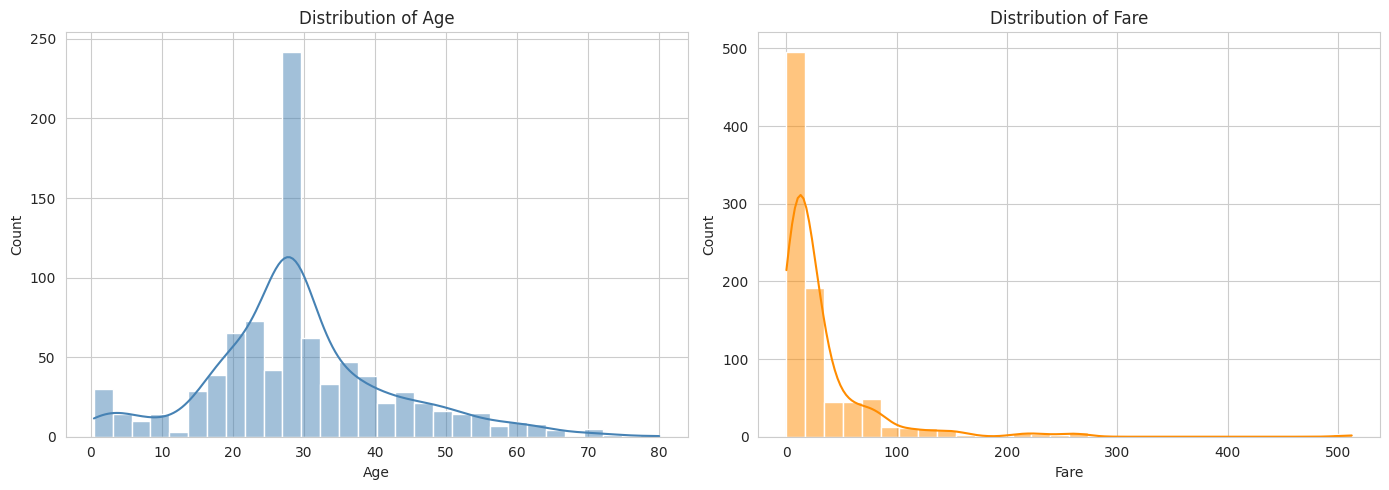

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(eda_df['Age'], bins=30, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution of Age')
sns.histplot(eda_df['Fare'], bins=30, kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Distribution of Fare')
plt.tight_layout()
plt.savefig('age_fare_hist.png', dpi=120)
plt.show()


**Observation:** `Age` is roughly bell-shaped with a concentration between 20–40 years, with a slight right skew from older passengers. `Fare` is heavily right-skewed — most passengers paid low fares, but a small number paid very high fares (likely 1st class passengers), creating a long tail.


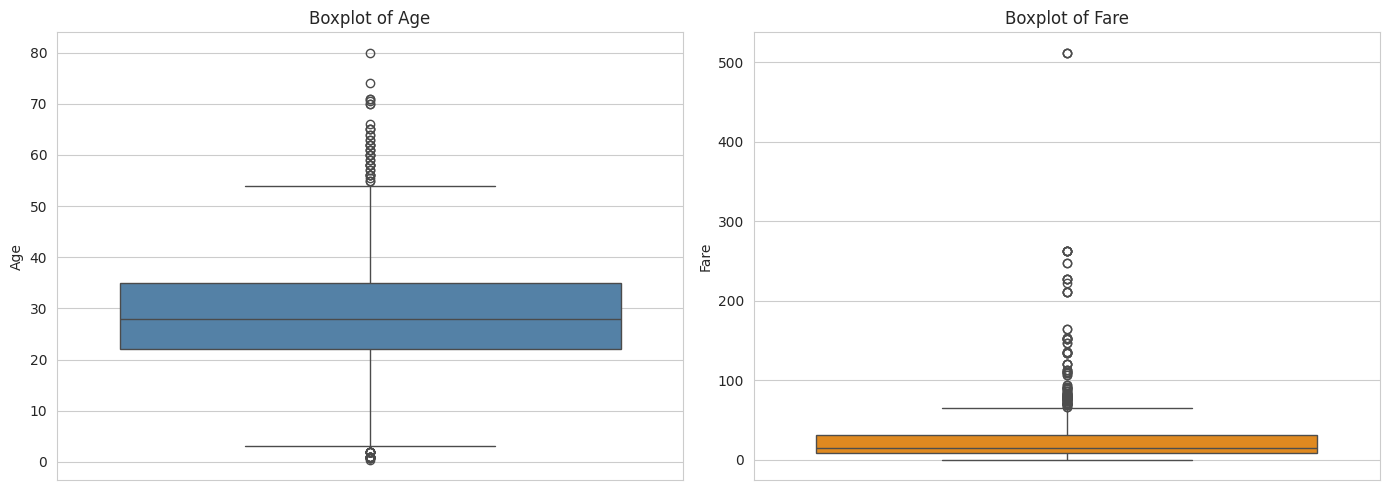

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(y=eda_df['Age'], ax=axes[0], color='steelblue')
axes[0].set_title('Boxplot of Age')
sns.boxplot(y=eda_df['Fare'], ax=axes[1], color='darkorange')
axes[1].set_title('Boxplot of Fare')
plt.tight_layout()
plt.savefig('age_fare_boxplot.png', dpi=120)
plt.show()


**Observation:** The Fare boxplot shows many outliers above the upper whisker, confirming the right-skew seen in the histogram. Age has a few outliers on the higher end (elderly passengers) but is otherwise fairly contained.


/tmp/ipykernel_582/3673858348.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=eda_df, ax=axes[0], palette='Set2')
/tmp/ipykernel_582/3673858348.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=eda_df, ax=axes[1], palette='Set2')


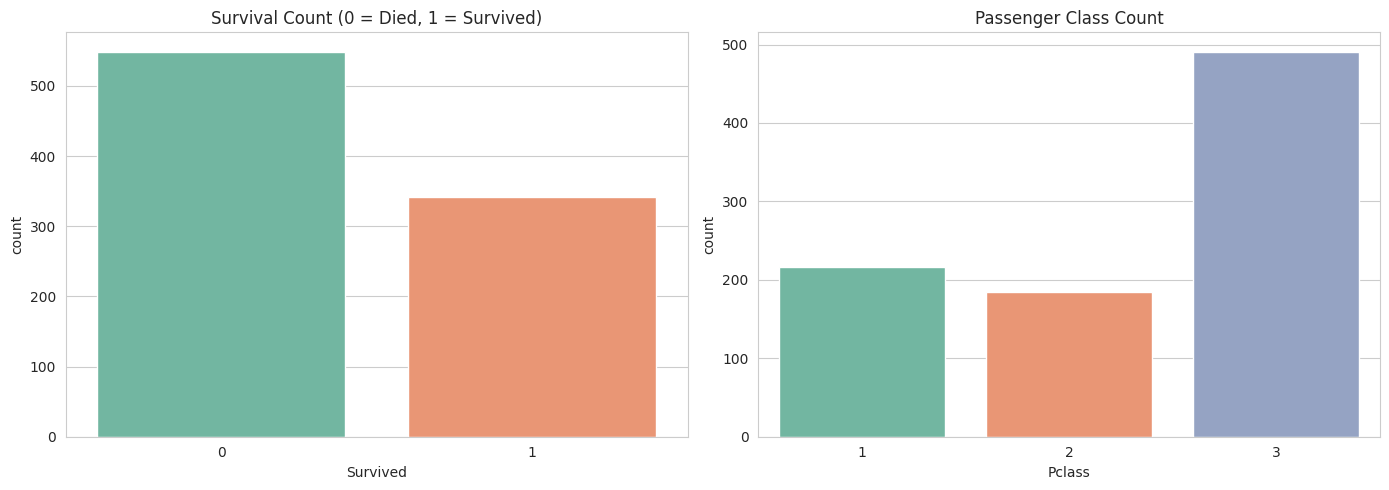

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='Survived', data=eda_df, ax=axes[0], palette='Set2')
axes[0].set_title('Survival Count (0 = Died, 1 = Survived)')
sns.countplot(x='Pclass', data=eda_df, ax=axes[1], palette='Set2')
axes[1].set_title('Passenger Class Count')
plt.tight_layout()
plt.savefig('survived_pclass_count.png', dpi=120)
plt.show()


**Observation:** Survival counts confirm the earlier `.value_counts()` — more passengers died than survived. Passenger class distribution shows 3rd class as the largest group, followed by 1st and then 2nd class.


## 5. Bivariate Analysis — Relationships Between Two Variables


/tmp/ipykernel_582/2460188369.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pclass', y='Survived', data=eda_df, palette='viridis', errorbar=None)


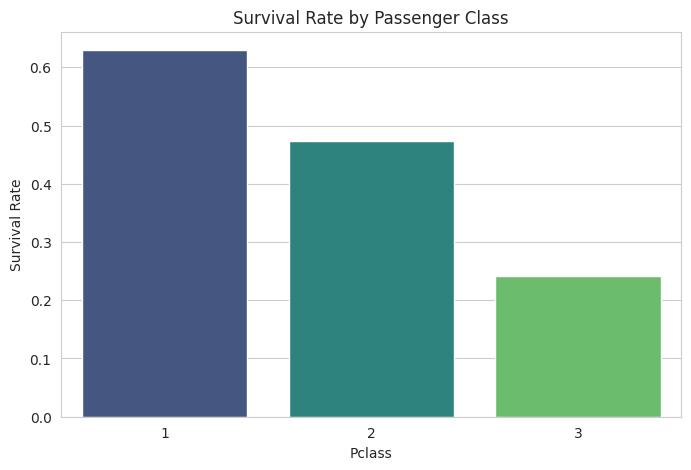

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(x='Pclass', y='Survived', data=eda_df, palette='viridis', errorbar=None)
plt.title('Survival Rate by Passenger Class')
plt.ylabel('Survival Rate')
plt.savefig('survival_by_class.png', dpi=120)
plt.show()


**Observation:** Survival rate drops sharply from 1st class (~63%) to 3rd class (~24%). This strongly suggests that socio-economic status (proxied by ticket class) played a major role in survival — likely tied to cabin location and lifeboat access priority.


/tmp/ipykernel_582/2792292129.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=eda_df, palette='magma', errorbar=None)


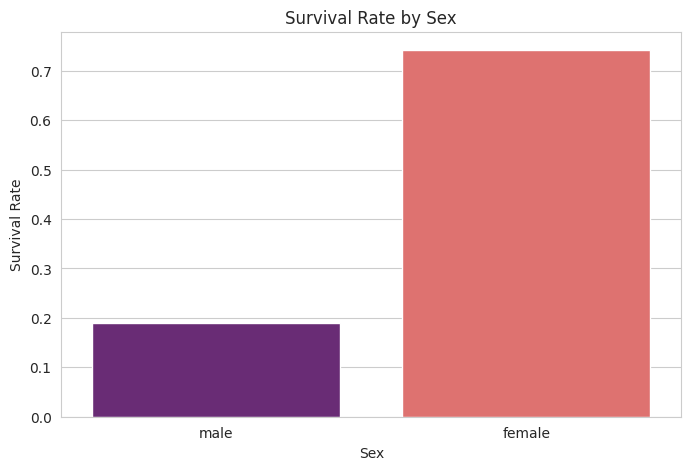

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(x='Sex', y='Survived', data=eda_df, palette='magma', errorbar=None)
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')
plt.savefig('survival_by_sex.png', dpi=120)
plt.show()


**Observation:** Survival rate for females (~74%) is dramatically higher than for males (~19%), consistent with the historical "women and children first" evacuation policy.


/tmp/ipykernel_582/1198930882.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Age', data=eda_df, palette='coolwarm')


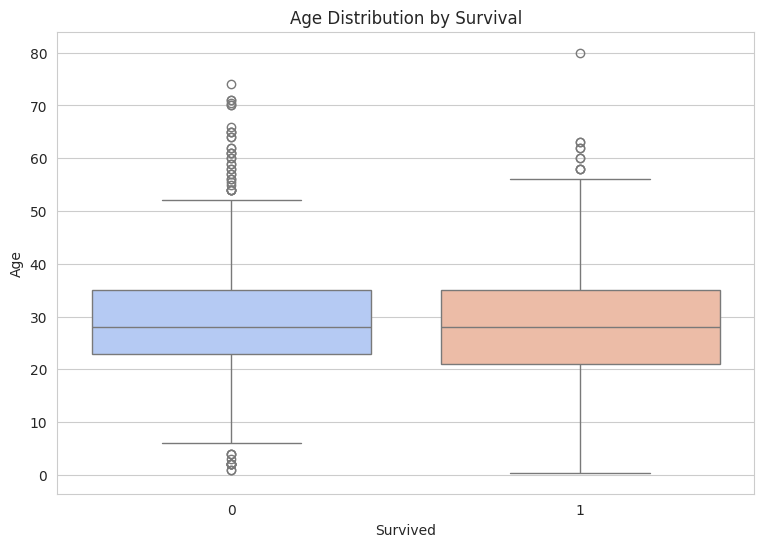

In [14]:
plt.figure(figsize=(9,6))
sns.boxplot(x='Survived', y='Age', data=eda_df, palette='coolwarm')
plt.title('Age Distribution by Survival')
plt.savefig('age_by_survival_boxplot.png', dpi=120)
plt.show()


**Observation:** Median age is similar for survivors and non-survivors, but survivors show a slightly wider spread toward younger ages — consistent with children being prioritized for evacuation.


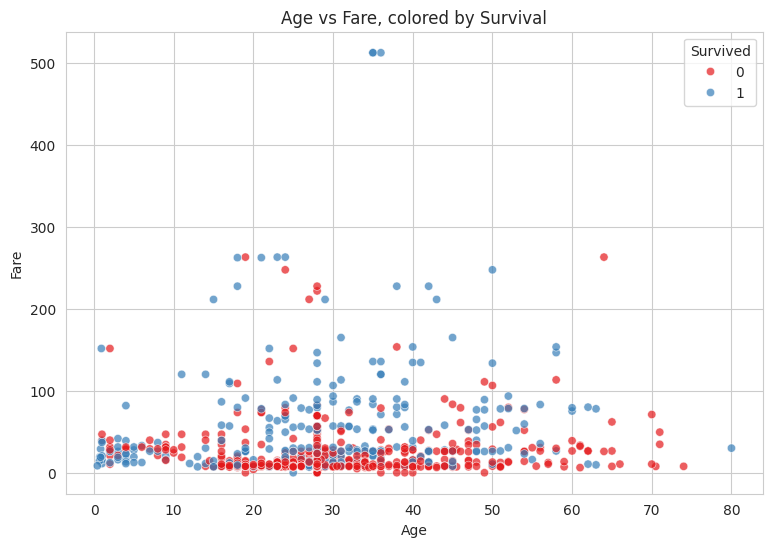

In [15]:
plt.figure(figsize=(9,6))
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=eda_df, palette='Set1', alpha=0.7)
plt.title('Age vs Fare, colored by Survival')
plt.savefig('age_vs_fare_scatter.png', dpi=120)
plt.show()


**Observation:** There's no strong linear relationship between Age and Fare. However, most high-fare passengers (top of the plot) survived, reinforcing that higher fare (correlated with class) improved survival odds regardless of age.


/tmp/ipykernel_582/463452576.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='FamilySize', y='Survived', data=eda_df, palette='crest', errorbar=None)


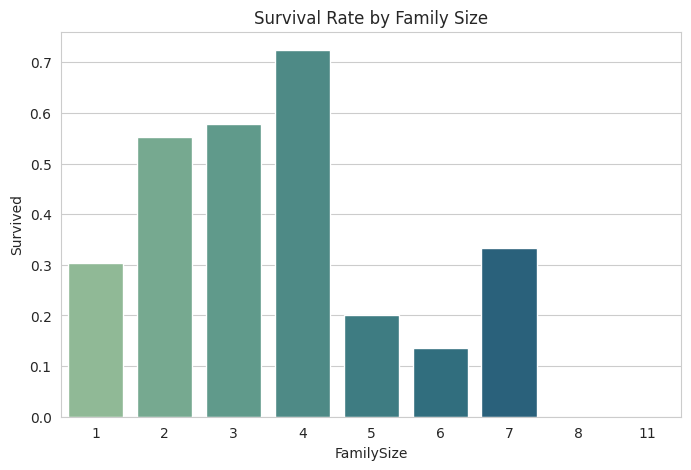

In [16]:
plt.figure(figsize=(8,5))
sns.barplot(x='FamilySize', y='Survived', data=eda_df, palette='crest', errorbar=None)
plt.title('Survival Rate by Family Size')
plt.savefig('survival_by_familysize.png', dpi=120)
plt.show()


**Observation:** Passengers traveling completely alone (FamilySize = 1) or in very large families (6+) had lower survival rates, while small families (2–4 members) had the best survival odds — likely a balance between having help evacuating and not being slowed down by a large group.


## 6. Multivariate Analysis — Pairplot & Heatmap


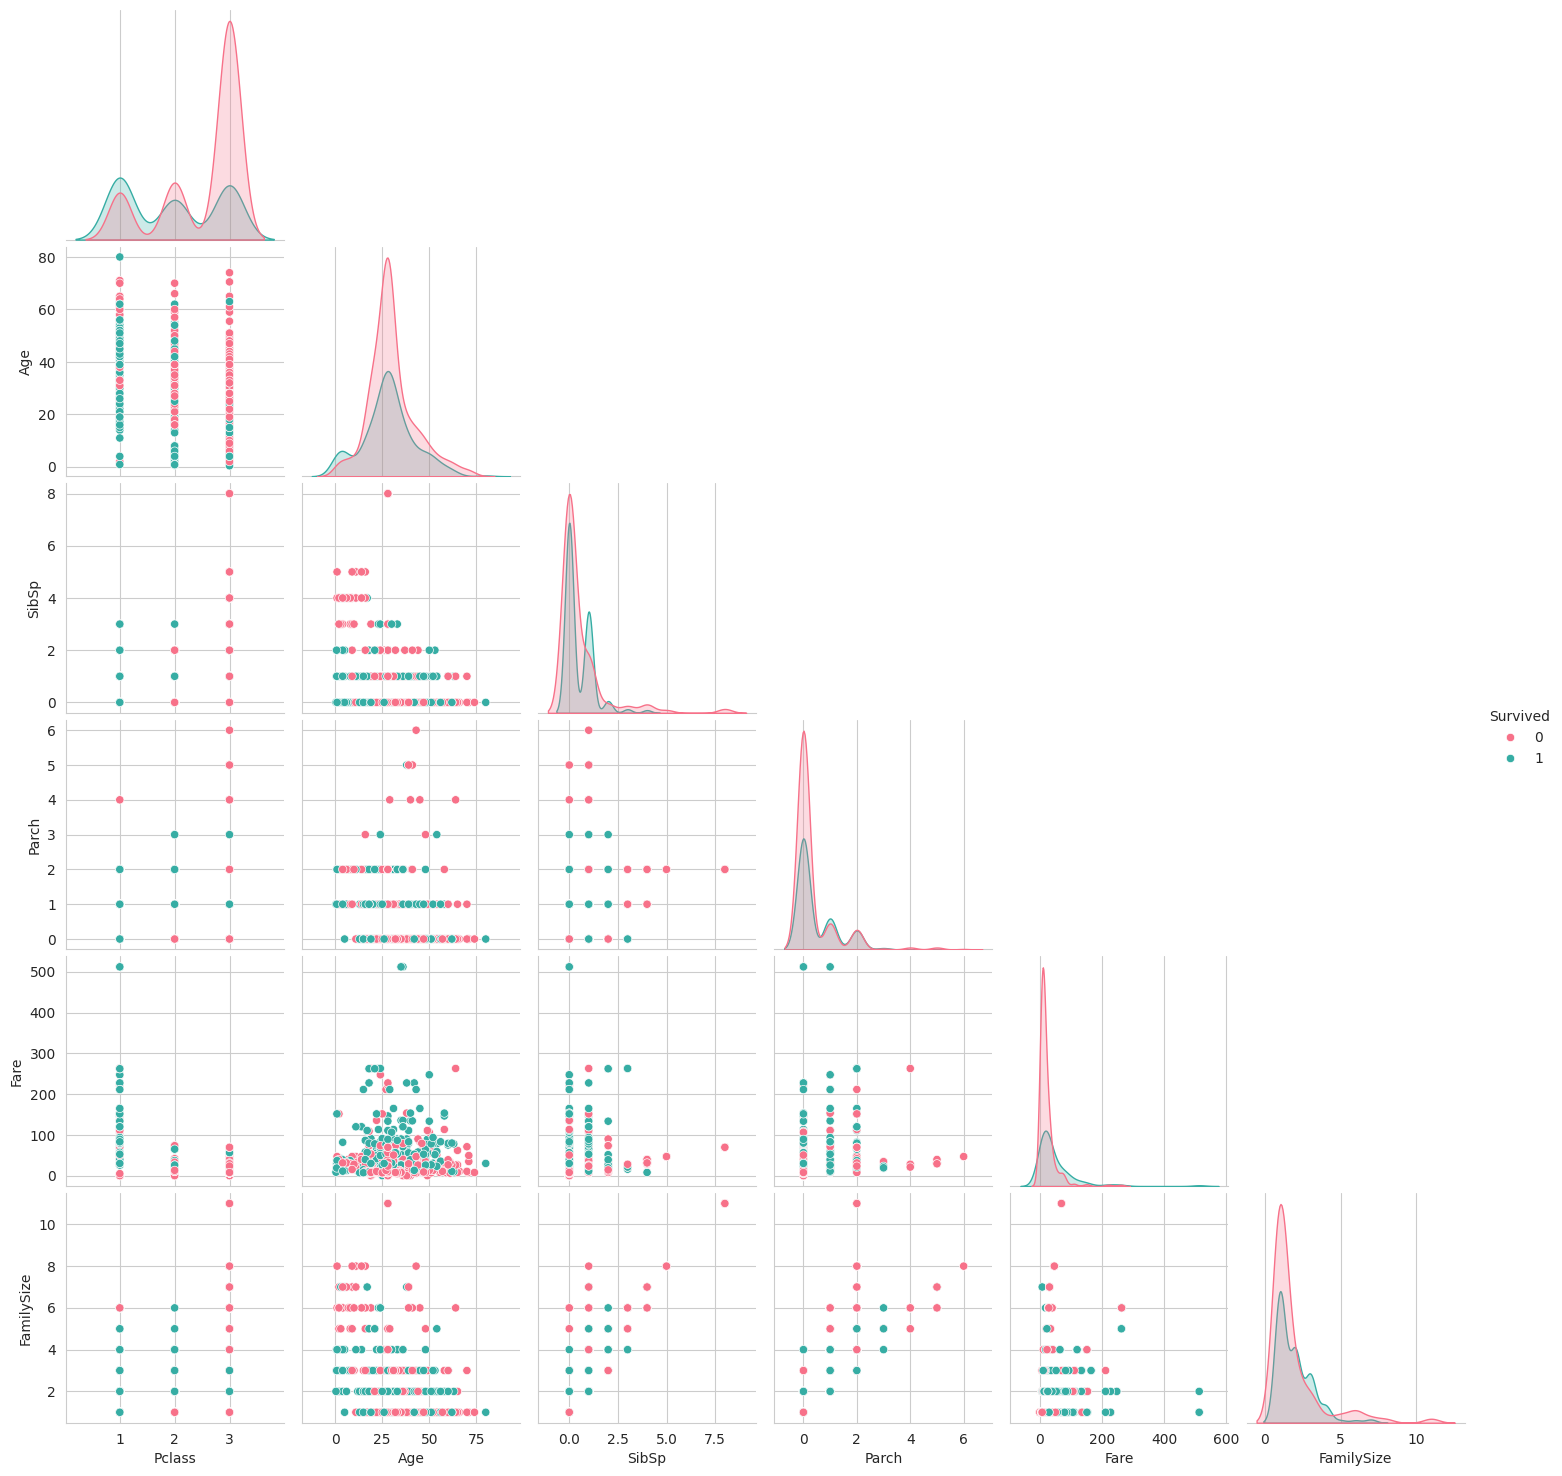

In [17]:
num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize']
sns.pairplot(eda_df[num_cols], hue='Survived', palette='husl', diag_kind='kde', corner=True)
plt.savefig('pairplot.png', dpi=120)
plt.show()


**Observation:** The pairplot lets us scan all numeric variable relationships at once. `Pclass` and `Fare` show a visible (inverse) relationship — lower class number pays more. Diagonal KDEs show `Survived=1` (orange/second hue) skews toward lower `Pclass` values and higher `Fare`, reinforcing earlier bivariate findings.


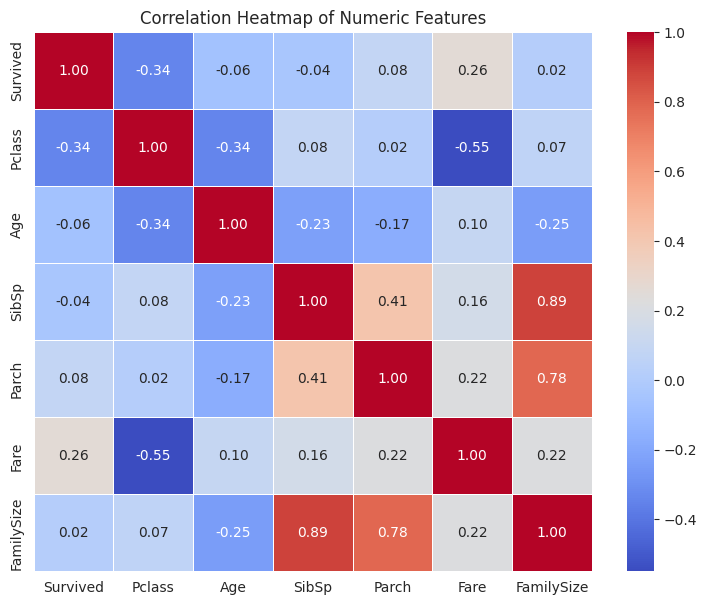

In [18]:
plt.figure(figsize=(9,7))
corr = eda_df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.savefig('heatmap.png', dpi=120)
plt.show()


**Observation:** `Fare` has the strongest positive correlation with `Survived` (~0.26), and `Pclass` has the strongest negative correlation with `Survived` (~-0.34). `SibSp` and `Parch` are positively correlated with each other and both contribute to `FamilySize` by construction, which is expected and not true multicollinearity concern for EDA purposes.


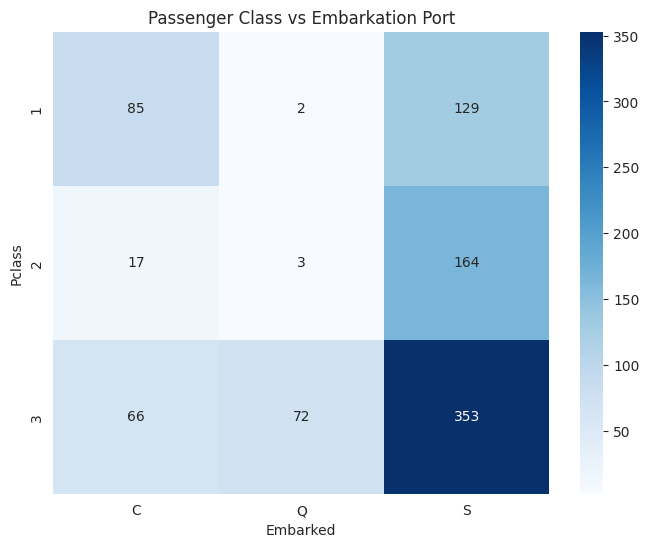

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(pd.crosstab(eda_df['Pclass'], eda_df['Embarked']), annot=True, fmt='d', cmap='Blues')
plt.title('Passenger Class vs Embarkation Port')
plt.savefig('class_vs_embarked.png', dpi=120)
plt.show()


**Observation:** Most passengers embarked from Southampton (S) across all classes. Cherbourg (C) has a notably higher proportion of 1st class passengers compared to the other two ports.


## 7. Summary of Findings

1. **Class matters most.** Survival rate falls sharply from 1st class (~63%) to 3rd class (~24%), and `Pclass` shows the strongest negative correlation with survival among numeric features.
2. **Sex is the single biggest predictor.** Female passengers survived at ~74% vs. ~19% for males, reflecting the "women and children first" protocol.
3. **Fare correlates with survival**, acting as a proxy for socio-economic status and cabin location, and shows the strongest positive correlation with `Survived`.
4. **Family size has a sweet spot.** Small families (2–4) survived at higher rates than solo travelers or very large families.
5. **Age distribution** is roughly normal with a concentration in the 20–40 range; children show a modestly higher survival tendency.
6. **Fare is right-skewed** with outliers from a small number of high-paying (mostly 1st class) passengers — this skew should be addressed (e.g., log transform) before use in linear models.
7. **Missing data:** `Cabin` (~77% missing) is likely unusable directly and would need engineering (e.g., "has cabin" flag); `Age` (~20% missing) was median-imputed for this EDA; `Embarked` had only 2 missing values.
8. No strong signs of problematic multicollinearity among the core numeric features other than the expected `SibSp`/`Parch`/`FamilySize` relationship (by construction).

**Conclusion:** Survival on the Titanic was driven primarily by **sex**, **passenger class**, and **fare** — all pointing to unequal evacuation access along social and gender lines — with **family size** playing a secondary role.


## 8. Interview Questions & Answers

**1. What is EDA and why is it important?**
Exploratory Data Analysis (EDA) is the process of visually and statistically examining a dataset to understand its structure, spot patterns, detect anomalies, and check assumptions before formal modeling. It's important because it guides feature engineering, reveals data quality issues (missing values, outliers), and prevents building models on flawed assumptions.

**2. Which plots do you use to check correlation?**
Scatterplots (for two continuous variables), pairplots (for multiple variables at once), and heatmaps of the correlation matrix (for a quick overview of all pairwise correlations).

**3. How do you handle skewed data?**
Apply transformations such as log, square-root, or Box-Cox to reduce skew; alternatively use robust scalers or bin the variable into categories. For tree-based models, skew is less of a concern, but for linear/distance-based models it should be corrected.

**4. How to detect multicollinearity?**
Use a correlation heatmap to spot highly correlated numeric features, or more formally compute the Variance Inflation Factor (VIF) for each feature — a VIF above ~5–10 typically signals problematic multicollinearity.

**5. What are univariate, bivariate, and multivariate analyses?**
- *Univariate*: examining one variable alone (histograms, boxplots, value counts).
- *Bivariate*: examining the relationship between two variables (scatterplots, grouped bar charts, boxplots by category).
- *Multivariate*: examining relationships among three or more variables simultaneously (pairplots with hue, heatmaps, multi-dimensional grouping).

**6. Difference between heatmap and pairplot?**
A heatmap visualizes a correlation matrix as a color-coded grid, giving a quick numeric-summary view of all pairwise linear relationships. A pairplot shows actual scatterplots (and distributions on the diagonal) for every pair of variables, revealing the shape of relationships (linear, non-linear, clustered) that a heatmap's single correlation number can't capture.

**7. How do you summarize your insights?**
By tying each visual observation back to the business/research question, ranking findings by impact (e.g., which features most strongly relate to the target variable), and writing a concise narrative summary (like the "Summary of Findings" section above) that a non-technical stakeholder could act on.
